In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import time

In [ ]:
# fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# Extract the 'features' (input data/predictors) into DataFrame X
X = phishing_websites.data.features
# Extract the 'targets' (the variable to be predicted: phishing or legitimate) into DataFrame y
y = phishing_websites.data.targets


df = pd.read_csv("https://archive.ics.uci.edu/static/public/327/data.csv")
# Print the first 5 rows of the DataFrame to visually check the data structure
print(df.head(5))


# Split the entire dataset into a training set and a test set
# X_train and y_train will be used to train the model while X_test and y_test will be used for final performance evaluation
# test_size=0.20 reserves 20% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Print the size (number of rows) of the training and test sets for confirmation
print(len(X_train), len(X_test))



   having_ip_address  url_length  shortining_service  having_at_symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  prefix_suffix  having_sub_domain  sslfinal_state  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   domain_registration_length  favicon  ...  popupwindow  iframe  \


In [ ]:
# Definition of the models with their parameters
models = {
    "Naive Bayes": (
        Pipeline([
            ("scaler", StandardScaler()),               # standardize data features (mean=0, std=1)
            ("pca", PCA(n_components=0.95)),             # apply PCA to reduce dimensionality, retaining 95% of variance
            ("clf", GaussianNB())                        # gaussian Naive Bayes Classifier
        ]),
        # Hyperparameters for Naive Bayes: var_smoothing controls stability
        {
            "clf__var_smoothing": np.logspace(-12, -6, 7)
        }
    ),

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("clf", LogisticRegression(max_iter=2000))   # max_iter increased to ensure model convergence
        ]),
        # Hyperparameters: C is the inverse of regularization strength
        {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    ),

    "Decision Tree": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("clf", DecisionTreeClassifier())
        ]),
        # Hyperparameters control tree growth to prevent overfitting
        {
            "clf__max_depth": [3, 5, 10, None],          # Maximum depth of the tree (None is unlimited)
            "clf__min_samples_split": [2, 10, 20]        # Minimum samples required to split an internal node
        }
    ),

    "Random Forest": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("clf", RandomForestClassifier())
        ]),
        # Hyperparameters tune the ensemble properties
        {
            "clf__n_estimators": [100, 200],             # Number of trees in the forest
            "clf__max_depth": [5, 10, None],
            "clf__min_samples_split": [2, 10]
        }
    ),

    "SVM (Kernel)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("clf", SVC(kernel="rbf", probability=True))  # probability=True allows prediction probabilities
        ]),
        # Hyperparameters control the non-linear decision boundary
        {
            "clf__C": [0.1, 1, 10],                        # Regularization strength
            "clf__gamma": ["scale", 0.01, 0.001]           # Kernel coefficient
        }
    ),

    "SVM (Linear)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("clf", SVC(kernel="linear", probability=True))
        ]),
        # Hyperparameters: Only C is relevant for the linear kernel
        {
            "clf__C": [0.1, 1, 10]
        }
    )
}

In [ ]:
# Initialize empty dictionaries to store results for later analysis
best_models = {}        # Stores the best version of each model found after tuning
model_cv_results = {}   # stores detailed cross-validation results
best_cv_scores = {}     # Stores the final best training and validation scores for each model
training_times = {}     # Records how long it takes to tune each model


# Iterate through the 'models' dictionary.
# 'name' is the model name (e.g., "Random Forest"), and (model, params) is the tuple containing the pipeline and the parameter grid
for name, (model, params) in models.items():
    print(f"\nTraining {name}...")

    # start Hyperparameter Tuning with GridSearchCV and record initial time
    start = time.time()
    grid = GridSearchCV(
        model,          # The pipeline model to tune
        params,         # The grid of hyperparameters to test
        cv=5,           # perform 5-fold cross-validation
        scoring="f1",   # Use the F1-score metric to determine the best model
        n_jobs=-1,      # Use all available CPU cores for faster computation
        return_train_score = True # Ensures that training scores are also recorded for variance analysis
    )

    # Run the grid search and cross-validation on the training data. Stop the timer
    grid.fit(X_train, y_train)
    end = time.time()
    training_times[name] = end - start
    # End Hyperparameter Tuning

    # Store and print results
    best_models[name] = grid.best_estimator_
    print("Best params:", grid.best_params_)
    print(f"Training time: {training_times[name]:.2f} seconds")


    # Extract and store detailed cross-validation results
    cv_df = pd.DataFrame(grid.cv_results_)
    model_cv_results[name] = cv_df[[
    "params",               # The parameter combination tested
    "mean_train_score",     # Average score on the training folds
    "mean_test_score",      # Average score on the validation folds
    "std_train_score",      # Standard deviation of the training scores
    "std_test_score",       # Standard deviation of the validation scores
    "rank_test_score"       # Rank of the parameter combination based on mean_test_score
    ]]

    # Record the final best scores (Training vs. Validation) achieved by the optimal parameters.
    idx = grid.best_index_
    best_cv_scores[name] = {
        "train_score": cv_df.loc[idx, "mean_train_score"],
        "val_score": cv_df.loc[idx, "mean_test_score"]
    }


# Print a table comparing the best Train vs Validation scores for all models.
print("\n TRAIN vs VALIDATION PERFORMANCE")
best_cv_scores_df = pd.DataFrame(best_cv_scores).T
print(best_cv_scores_df)


Training Naive Bayes...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params: {'clf__var_smoothing': np.float64(1e-12)}
Training time: 9.85 seconds

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params: {'clf__C': 0.1}
Training time: 2.21 seconds

Training Decision Tree...
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2}
Training time: 23.42 seconds

Training Random Forest...


...

Best params: {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 100}
Training time: 207.01 seconds

Training SVM (Kernel)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
Training time: 322.92 seconds

Training SVM (Linear)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params: {'clf__C': 1}
Training time: 158.52 seconds

 TRAIN vs VALIDATION PERFORMANCE
                     train_score  val_score
Naive Bayes             0.914205   0.913278
Logistic Regression     0.937227   0.935759
Decision Tree           0.991909   0.948235
Random Forest           0.988987   0.965251
SVM (Kernel)            0.980712   0.966096
SVM (Linear)            0.935780   0.934900


In [ ]:
def plot_learning_curve(model, X, y, title):
    # calculate scores on training and validation sets as training size increases.
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,                             # Use 5-fold cross-validation
        scoring="f1",                     # Metric used is F1-score
        train_sizes=np.linspace(0.1, 1.0, 8), # Define sample training set sizes
        n_jobs=-1                         # Use all cores
    )

    # Calculate mean and standard deviation for training and validation scores.
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    # Plot details
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # Plot the mean scores
    plt.plot(train_sizes, train_mean, label="Training score")
    plt.plot(train_sizes, val_mean, label="Validation score")

    # Shade the area representing the standard deviation.
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    # Add labels, legend, and grid
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()


=== Naive Bayes ===
Accuracy: 0.8968792401628223
F1: 0.9095238095238095
AUC: 0.9597067795762557
precision: 0.9059288537549407
recall: 0.9131474103585657
confusion matrix: [[ 837  119]
 [ 109 1146]]


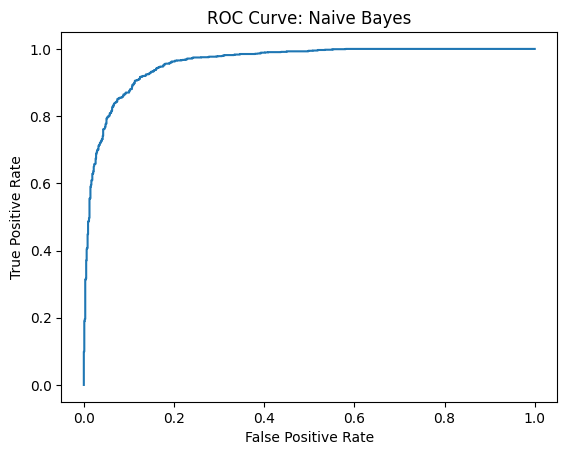


Learning Curve for Naive Bayes


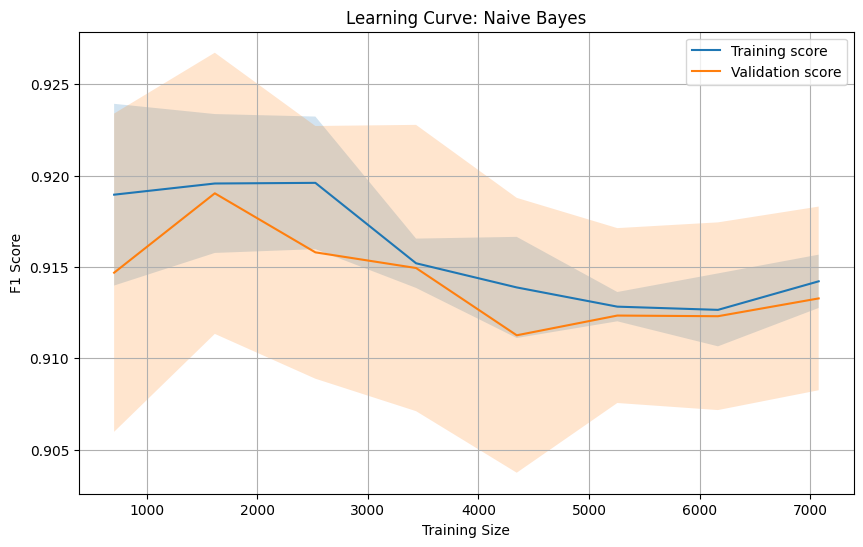


=== Logistic Regression ===
Accuracy: 0.9231117141564903
F1: 0.9329123914759274
AUC: 0.9770466252146227
precision: 0.9241594996090696
recall: 0.9418326693227091
confusion matrix: [[ 859   97]
 [  73 1182]]


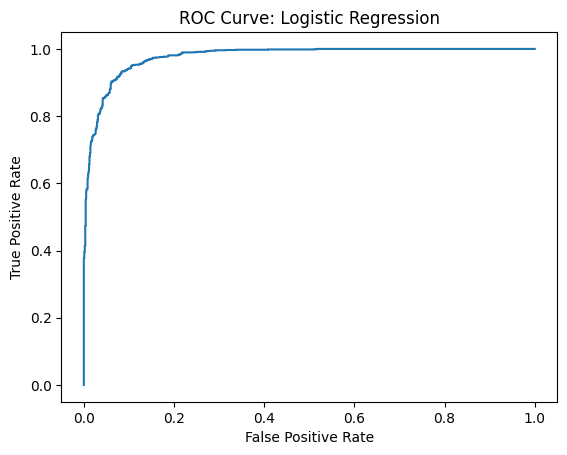


Learning Curve for Logistic Regression


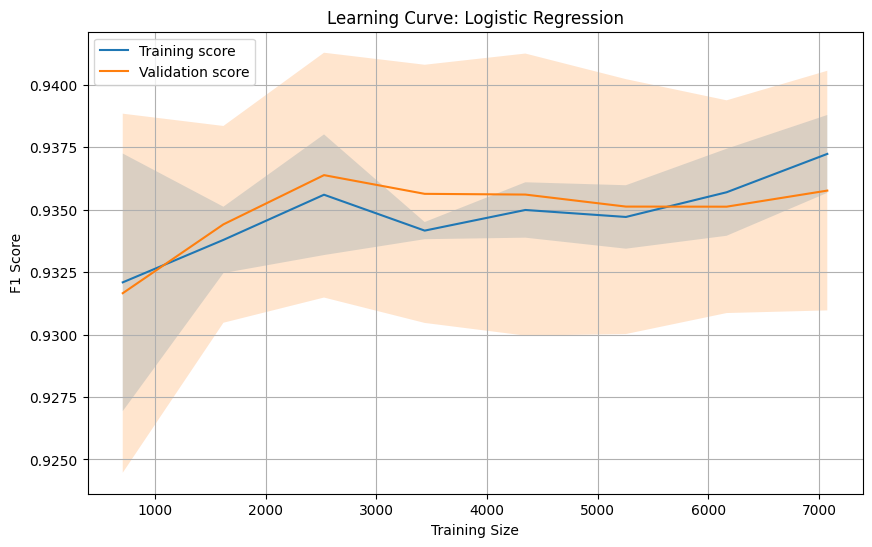


=== Decision Tree ===
Accuracy: 0.9448213478064225
F1: 0.9517405063291139
AUC: 0.9578739435563187
precision: 0.9450117831893166
recall: 0.9585657370517928
confusion matrix: [[ 886   70]
 [  52 1203]]


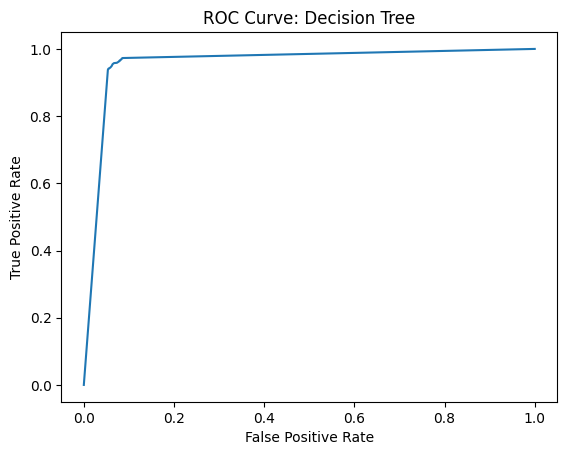


Learning Curve for Decision Tree


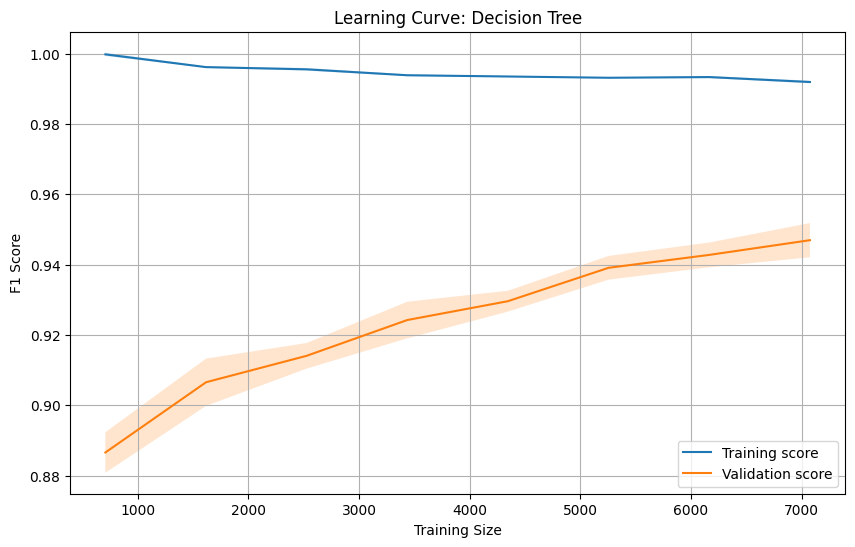


=== Random Forest ===
Accuracy: 0.9579375848032564
F1: 0.9632846427161469
AUC: 0.9913642501125206
precision: 0.9546165884194053
recall: 0.9721115537848606
confusion matrix: [[ 898   58]
 [  35 1220]]


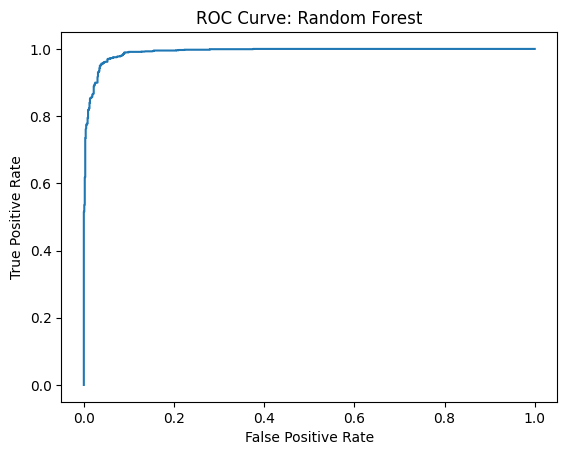


Learning Curve for Random Forest


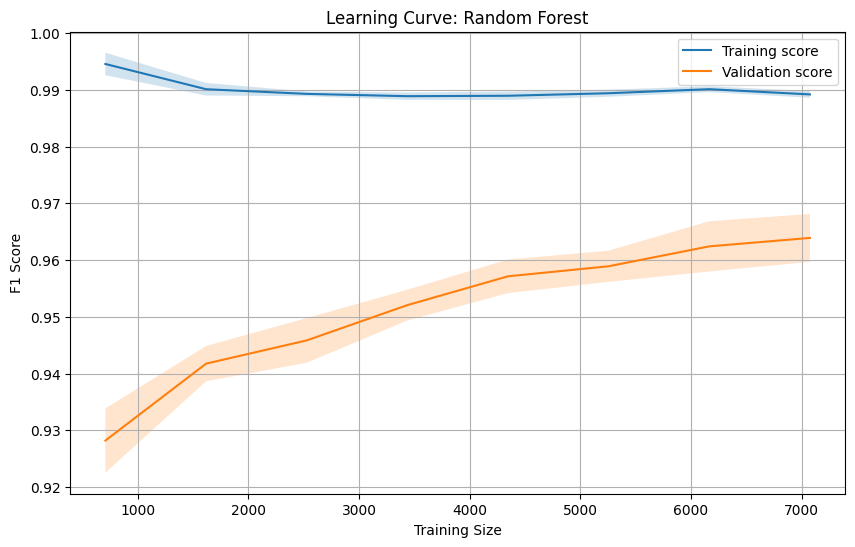


=== SVM (Kernel) ===
Accuracy: 0.9620081411126187
F1: 0.966903073286052
AUC: 0.9908166497191151
precision: 0.9563522992985191
recall: 0.9776892430278884
confusion matrix: [[ 900   56]
 [  28 1227]]


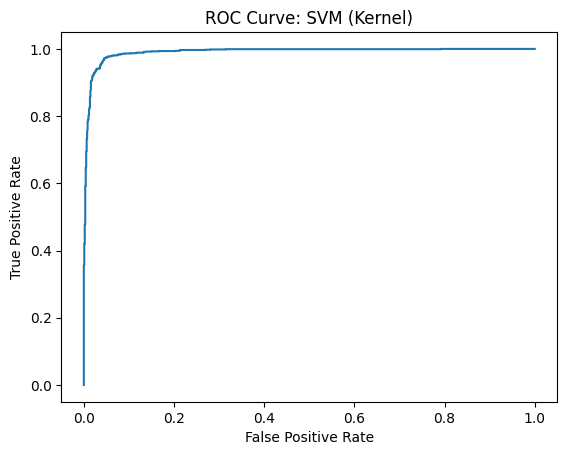


Learning Curve for SVM (Kernel)


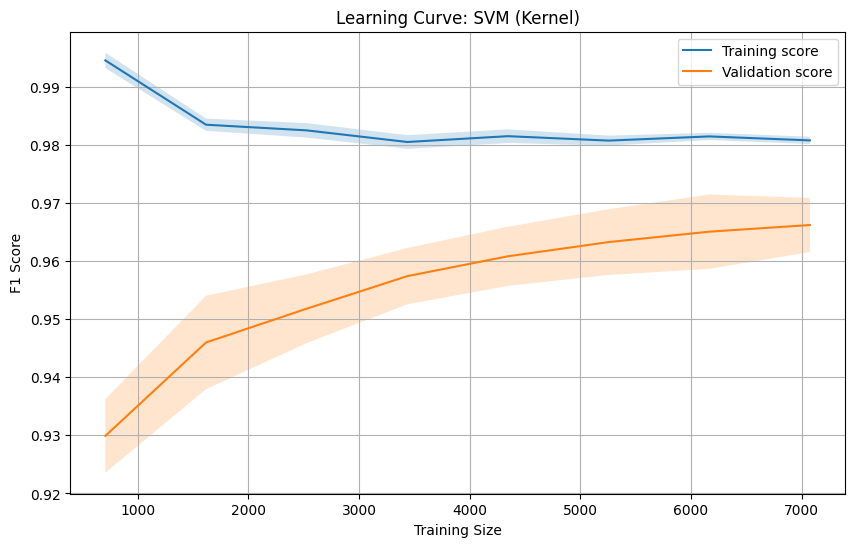


=== SVM (Linear) ===
Accuracy: 0.9258254183627318
F1: 0.9355852317360566
AUC: 0.9767490706629548
precision: 0.9225406661502711
recall: 0.949003984063745
confusion matrix: [[ 856  100]
 [  64 1191]]


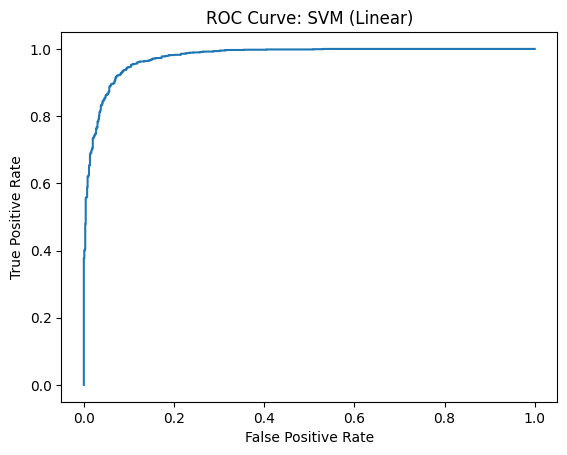


Learning Curve for SVM (Linear)


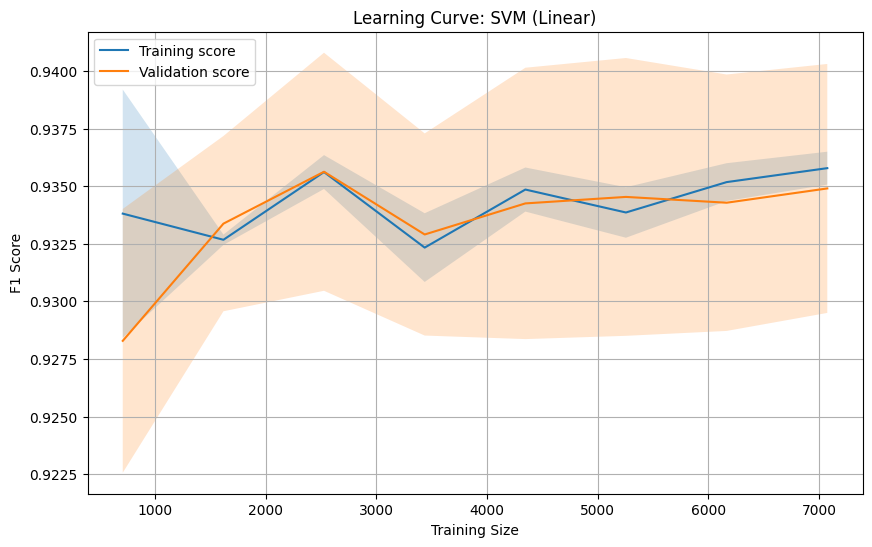

In [ ]:
results = {}

# Loop through the dictionary of best models for testing them
for name, model in best_models.items():
    # Predict the class labels (0 or 1) for the test set
    y_test_pred = model.predict(X_test)
    # Predict the probability of the positive class (class 1) for AUC/ROC curve calculation
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Calculate Performance Metrics
    test_acc = accuracy_score(y_test, y_test_pred)     # overall correct predictions
    test_f1 = f1_score(y_test, y_test_pred)            # harmonic mean of precision and recall
    test_auc = roc_auc_score(y_test, y_test_proba)    # area under the receiver operating characteristic curve
    precision = precision_score(y_test, y_test_pred)  # ratio of true positive predictions to total positive predictions
    recall = recall_score(y_test, y_test_pred)        # ratio of true positive predictions to all actual positives
    cm = confusion_matrix(y_test, y_test_pred)        # calculates the Confusion Matrix
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba) # calculates False Positive Rate and True Positive Rate

    # Store all calculated metrics and curves/matrices in the results dictionary
    results[name] = (test_acc, test_f1, test_auc, precision, recall, cm, fpr, tpr, thresholds)

    # print Summary and Plot Results
    print(f"\n=== {name} ===")
    print("Accuracy:", test_acc)
    print("F1:", test_f1)
    print("AUC:", test_auc)
    print("precision:", precision)
    print("recall:", recall)
    print("confusion matrix:", cm)


    # Plot the ROC curve
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: "+ name)
    plt.show()

    # Generate and plot the Learning Curve for the current model.
    print(f"\nLearning Curve for {name}")
    plot_learning_curve(model, X_train, y_train, title=f"Learning Curve: {name}")